In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("Bank_Churn_.csv")
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619.0,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608.0,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502.0,France,Female,NaN,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699.0,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850.0,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10295,15574283,Padovano,580.0,France,Male,31.0,2,0.00,2,0,1,64014.24,0
10296,15753213,Lees,604.0,France,Female,34.0,7,0.00,2,1,0,193021.49,0
10297,15738936,Stevenson,760.0,Germany,Male,29.0,5,103607.24,2,0,1,86334.64,0
10298,15587013,Tien,653.0,France,Female,31.0,7,102575.04,1,1,1,11043.54,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10300 non-null  int64  
 1   Surname          10300 non-null  object 
 2   CreditScore      9897 non-null   object 
 3   Geography        10300 non-null  object 
 4   Gender           10300 non-null  object 
 5   Age              9698 non-null   float64
 6   Tenure           10300 non-null  int64  
 7   Balance          9882 non-null   float64
 8   NumOfProducts    10300 non-null  int64  
 9   HasCrCard        10300 non-null  int64  
 10  IsActiveMember   10300 non-null  int64  
 11  EstimatedSalary  9887 non-null   float64
 12  Exited           10300 non-null  int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 1.0+ MB


In [4]:
df.head(40)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619.0,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608.0,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502.0,France,Female,NaN,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699.0,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850.0,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0
5,15574012,Chu,645.0,Spain,Male,44.0,8,113755.78,2,1,0,149756.71,1
6,15592531,Bartlett,822.0,France,Male,50.0,7,0.00,2,1,1,10062.80,0
7,15656148,Obinna,376.0,Germany,Female,29.0,4,115046.74,4,1,0,119346.88,1
8,15792365,He,NaN,France,Male,44.0,4,142051.07,2,0,1,74940.50,0
9,15592389,H?,684.0,France,Male,27.0,2,134603.88,1,1,1,71725.73,0


In [5]:
df.isnull().sum()

CustomerId           0
Surname              0
CreditScore        403
Geography            0
Gender               0
Age                602
Tenure               0
Balance            418
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    413
Exited               0
dtype: int64

In [6]:
df["CustomerId"].duplicated().sum()


np.int64(300)

In [7]:
df[df["CustomerId"].duplicated(keep=False)].sort_values("CustomerId")


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7737,15566563,Duigan,777.0,France,Female,30.0,4,137851.31,1,1,0,5008.23,1
10102,15566563,Duigan,777.0,France,Female,30.0,4,137851.31,1,1,0,5008.23,1
9112,15567339,Shaw,735.0,France,Male,73.0,9,0.00,1,1,1,114283.33,0
10087,15567339,Shaw,735.0,France,Male,73.0,9,0.00,1,1,1,114283.33,0
10248,15569666,Goddard,517.0,France,Female,45.0,4,0.00,1,0,0,172674.36,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,15814040,Munroe,610.0,France,Female,45.0,1,0.00,2,1,1,199657.46,0
5919,15815043,McMillan,645.0,Spain,Male,49.0,8,0.00,2,1,0,162012.60,0
10189,15815043,McMillan,645.0,Spain,Male,49.0,8,0.00,2,1,0,162012.60,0
10008,15815560,Bogle,666.0,Germany,Male,74.0,7,105102.50,1,1,1,46172.47,0


In [8]:
df[df.duplicated()].shape


(124, 13)

In [9]:
df = df.drop_duplicates()


In [10]:
df["CustomerId"].duplicated().sum()


np.int64(176)

In [11]:
df = df.drop_duplicates(subset="CustomerId", keep="first")


In [12]:
df["CustomerId"].duplicated().sum()


np.int64(0)

now surname

In [13]:
df["Surname"] = df["Surname"].str.strip()


In [14]:
df["Surname"].str.contains("  ").sum()


np.int64(0)

credit score

In [15]:
df["CreditScore"].dtype
df["CreditScore"].head(5)


0    619.0
1    608.0
2    502.0
3    699.0
4    850.0
Name: CreditScore, dtype: object

In [16]:
df["CreditScore"] = pd.to_numeric(df["CreditScore"], errors="coerce")


In [17]:
df.loc[(df["CreditScore"]<300)|(df["CreditScore"]>900),"CreditScore"]=None


In [18]:
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].median())


In [19]:
df.isnull().sum()

CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                584
Tenure               0
Balance            400
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    400
Exited               0
dtype: int64

In [20]:
df["Geography"] = df["Geography"].str.strip().str.lower()


In [21]:
df["Gender"] = df["Gender"].str.strip().str.lower()


AGE

In [22]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")


In [23]:
df.loc[(df["Age"]<18)|(df["Age"]>100),"Age"]=None


In [24]:
df["Age"] = df["Age"].fillna(df["Age"].median())


In [25]:
df.isnull().sum()

CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance            400
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    400
Exited               0
dtype: int64

In [26]:
df["Tenure"].describe()
df["Tenure"].unique()


array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0, 99])

so there is an impossible value in tenure [99]

In [27]:
df.loc[df["Tenure"]>10,"Tenure"]=None
df["Tenure"] = df["Tenure"].fillna(df["Tenure"].median())


In [28]:
df["balance_missing"] = df["Balance"].isna()
df["Balance"] = pd.to_numeric(df["Balance"], errors="coerce")
df.loc[df["Balance"]<0,"Balance"]=None
df["Balance"] = df.groupby("Geography")["Balance"].transform(
    lambda x: x.fillna(x.median())
)
df["Balance"] = df["Balance"].fillna(df["Balance"].median())



In [29]:
df.isnull().sum()

CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    400
Exited               0
balance_missing      0
dtype: int64

In [30]:
df.loc[df["NumOfProducts"]<=0,"NumOfProducts"]=1


In [31]:
df["HasCrCard"] = df["HasCrCard"].astype(int)


salary

In [32]:
df["EstimatedSalary"] = pd.to_numeric(df["EstimatedSalary"], errors="coerce")
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(df["EstimatedSalary"].median())


In [33]:
df["Exited"].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

In [34]:
df.isna().sum()
df.describe()
df.dtypes


CustomerId           int64
Surname             object
CreditScore        float64
Geography           object
Gender              object
Age                float64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
balance_missing       bool
dtype: object

In [35]:
df.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
balance_missing    0
dtype: int64

Feature engineering

In [36]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["Young", "Mid", "Senior", "Elder"]
)


In [37]:
# insight

df.groupby("AgeGroup")["Exited"].mean()


C:\Users\amald\AppData\Local\Temp\ipykernel_26152\2447966477.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Exited"].mean()


AgeGroup
Young     0.073553
Mid       0.163408
Senior    0.509349
Elder     0.240909
Name: Exited, dtype: float64

balance to salary ratio

In [38]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)


In [39]:
#insight
df.groupby("Exited")["BalanceSalaryRatio"].median()


Exited
0    0.700662
1    0.898505
Name: BalanceSalaryRatio, dtype: float64

In [40]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_missing,AgeGroup,BalanceSalaryRatio
0,15634602,Hargrave,619.0,france,female,42.0,2.0,0.00,1,1,1,101348.88,1,False,Mid,0.000000
1,15647311,Hill,608.0,spain,female,41.0,1.0,83807.86,1,0,1,112542.58,0,False,Mid,0.744670
2,15619304,Onio,502.0,france,female,37.0,8.0,159660.80,3,1,0,113931.57,1,False,Mid,1.401362
3,15701354,Boni,699.0,france,female,39.0,1.0,0.00,2,0,0,93826.63,0,False,Mid,0.000000
4,15737888,Mitchell,850.0,spain,female,43.0,2.0,125510.82,1,1,1,79084.10,0,False,Mid,1.587035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771.0,france,male,39.0,5.0,0.00,2,1,0,96270.64,0,False,Mid,0.000000
9996,15569892,Johnstone,516.0,france,male,35.0,10.0,57369.61,1,1,1,101699.77,0,False,Mid,0.564102
9997,15584532,Liu,709.0,france,female,36.0,7.0,57213.00,1,0,1,42085.58,1,True,Mid,1.359412
9998,15682355,Sabbatini,772.0,germany,male,42.0,3.0,75075.31,2,1,0,92888.52,1,False,Mid,0.808222


Lets analyse churn rate

In [41]:
analysis_cols = df.columns.difference(["CustomerId","Surname"])
df_analysis = df[analysis_cols]


In [42]:
df_analysis["Exited"].value_counts()
df_analysis["Exited"].value_counts(normalize=True)*100


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

only 20.37 percentage churned and 79.63 percentage still sustain

In [43]:
df_analysis.describe()


,Age,Balance,BalanceSalaryRatio,CreditScore,EstimatedSalary,Exited,HasCrCard,IsActiveMember,NumOfProducts,Tenure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,38.782500,75778.499866,3.669837,650.598300,100011.056303,0.203700,0.70550,0.515100,1.530200,5.011200
std,10.211289,61333.648274,99.947158,93.910307,56339.533701,0.402769,0.45584,0.499797,0.581654,2.870069
min,18.000000,0.000000,0.000000,350.000000,11.580000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,32.000000,0.000000,0.000000,588.000000,53150.472500,0.000000,0.00000,0.000000,1.000000,3.000000
50%,37.000000,94623.185000,0.745299,652.000000,100238.110000,0.000000,1.00000,1.000000,1.000000,5.000000
75%,43.000000,125919.757500,1.467413,713.000000,146908.955000,0.000000,1.00000,1.000000,2.000000,7.000000
max,92.000000,250898.090000,9770.883148,850.000000,199970.740000,1.000000,1.00000,1.000000,4.000000,10.000000


In [44]:
(df["EstimatedSalary"] < 0).sum()


np.int64(0)

no negative values for estimated salary
lets check balance

In [45]:
(df["Balance"] < 0).sum()
df[df["Balance"] < 0].describe()


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


we can see unreal values like -190409

In [46]:
Q1 = df["Balance"].quantile(0.25)
Q3 = df["Balance"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
lower_bound


np.float64(-188879.63625)

In [47]:
(df["Balance"] < -190956.8925).sum()


np.int64(0)

In [48]:
df[df["Balance"] < -190956.8925]


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_missing,AgeGroup,BalanceSalaryRatio


In [49]:
df.loc[df["Balance"] < lower_bound, "Balance"] = None
df["Balance"].fillna(df["Balance"].median(), inplace=True)


Catogarical distribution

In [50]:
for col in ["Geography","Gender","NumOfProducts","HasCrCard","IsActiveMember"]:
    print(df_analysis[col].value_counts())
    print("------")


Geography
france     5014
germany    2509
spain      2477
Name: count, dtype: int64
------
Gender
male       5367
female     4443
unknown      96
?            94
Name: count, dtype: int64
------
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
------
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
------
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
------


How many peoples are featuring and how many churned ,age wise analysis

In [51]:
age_bins = pd.cut(df_analysis["Age"], bins=[18,30,45,60,100])
pd.crosstab(age_bins, df_analysis["Exited"], normalize="index")*100


Exited,0,1
Age,,
"(18, 30]",92.644673,7.355327
"(30, 45]",83.659172,16.340828
"(45, 60]",49.065119,50.934881
"(60, 100]",75.909091,24.090909


We can see that peoples between the age 45-60 are likley churned more

now we are going to analyse the churned customer by there balance

In [52]:
balance_bins = pd.qcut(df_analysis["Balance"], q=4, duplicates="drop")
pd.crosstab(balance_bins, df_analysis["Exited"], normalize="index")*100


Exited,0,1
Balance,,
"(-0.001, 94623.185]",84.50,15.50
"(94623.185, 125919.758]",73.52,26.48
"(125919.758, 250898.09]",76.00,24.00


the peoples having balance between 95k and 120k churned more ,should be careful 

In [53]:
df_analysis.groupby(df_analysis["Balance"]==0)["Exited"].mean()*100


Balance
False    23.933722
True     13.699024
Name: Exited, dtype: float64

a number of people having zero balance also churned but not in huge number ,still in concern

we are analysing churned customers by there credit score now

In [54]:
score_bins = pd.cut(df_analysis["CreditScore"], bins=[300,580,670,740,850])
pd.crosstab(score_bins, df_analysis["Exited"], normalize="index")*100


Exited,0,1
CreditScore,,
"(300, 580]",77.949624,22.050376
"(580, 670]",79.628633,20.371367
"(670, 740]",81.227915,18.772085
"(740, 850]",79.738190,20.261810


credit score from 300-500 are likely the most to churn ,

we need to find most churned customers by country or specific region

In [55]:
pd.crosstab(df_analysis["Geography"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
Geography,,
france,83.845233,16.154767
germany,67.556796,32.443204
spain,83.326605,16.673395


Germany peoples churned the most

In [56]:
pd.crosstab(df_analysis["Gender"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
Gender,,
?,88.297872,11.702128
female,74.994373,25.005627
male,83.379914,16.620086
unknown,76.041667,23.958333


females are the most to churn

In [57]:
pd.crosstab(df_analysis["NumOfProducts"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [58]:
pd.crosstab(df_analysis["IsActiveMember"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


inactive members churns the most ,good

In [59]:
pd.crosstab(df_analysis["HasCrCard"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


kind a breakeven but slightly high for the no credit card induviduals to churn 

In [60]:
tenure_bins = pd.cut(df_analysis["Tenure"], bins=[0,3,6,10])
pd.crosstab(tenure_bins, df_analysis["Exited"], normalize="index")*100


Exited,0,1
Tenure,,
"(0, 3]",79.056047,20.943953
"(3, 6]",79.693611,20.306389
"(6, 10]",80.374101,19.625899


kind a break even but 0-3 years tenure period induviuals possses chance to churn

In [61]:
df_analysis.groupby("Exited").mean(numeric_only=True)


,Age,Balance,BalanceSalaryRatio,CreditScore,EstimatedSalary,HasCrCard,IsActiveMember,NumOfProducts,Tenure,balance_missing
Exited,,,,,,,,,,
0,37.366947,71971.919969,2.342796,651.778727,99628.518267,0.707146,0.554565,1.544267,5.029386,0.039432
1,44.316151,90659.106505,8.857481,645.983800,101506.466406,0.699067,0.360825,1.475209,4.940108,0.042219


In [62]:
pd.crosstab(
    [df_analysis["IsActiveMember"], df_analysis["NumOfProducts"]],
    df_analysis["Exited"],
    normalize="index"
)*100


Exited                                0           1
IsActiveMember NumOfProducts                       
0              1              63.347878   36.652122
               2              90.111940    9.888060
               3              11.764706   88.235294
               4               0.000000  100.000000
1              1              81.076863   18.923137
               2              94.439902    5.560098
               3              24.778761   75.221239
               4               0.000000  100.000000

In [63]:
pd.crosstab(df_analysis["balance_missing"], df_analysis["Exited"], normalize="index")*100


Exited,0,1
balance_missing,,
False,79.677083,20.322917
True,78.500000,21.500000


Visualization

In [64]:
df["Exited"].value_counts(normalize=True)*100


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

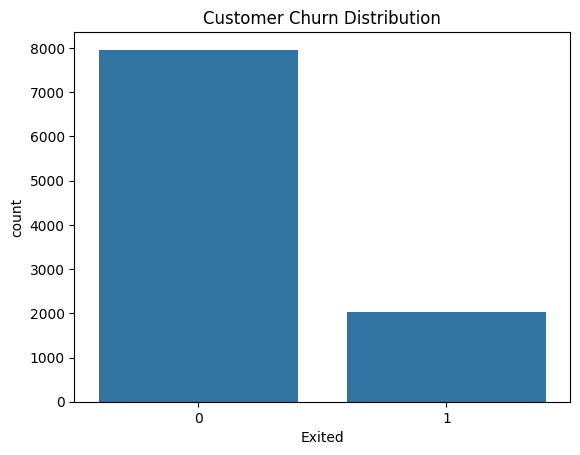

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()


In [66]:
churn_geo = df.groupby("Geography")["Exited"].mean()*100


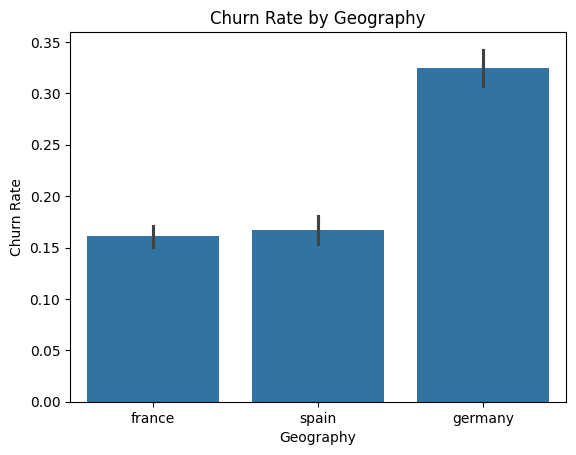

In [67]:
sns.barplot(x="Geography", y="Exited", data=df)
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.show()


Germans are likeley to churn more

so,Conduct customer satisfaction survey in Germany

Offer loyalty incentives specifically in Germany

Analyze German customer demographics deeper

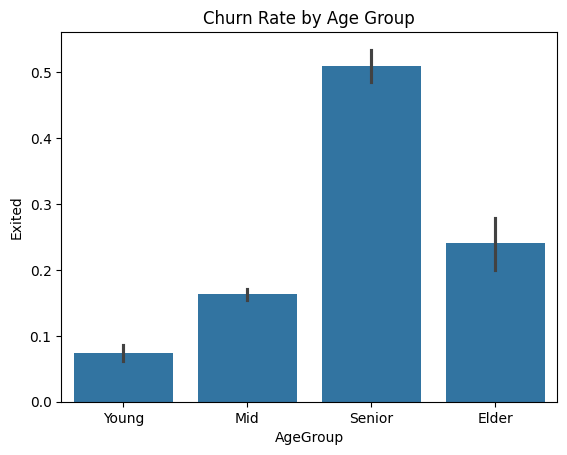

In [68]:
sns.barplot(x="AgeGroup", y="Exited", data=df)
plt.title("Churn Rate by Age Group")
plt.show()


 senior peoples are churned more 

So,Create senior-focused loyalty programs

Offer relationship manager support

Study financial behavior of seniors

In [69]:
df['CreditScoreGroup'] = pd.cut(
    df['CreditScore'],
    bins=[300, 500, 600, 700, 800, 900],
    labels=['300-500', '500-600', '600-700', '700-800', '800-900']
)


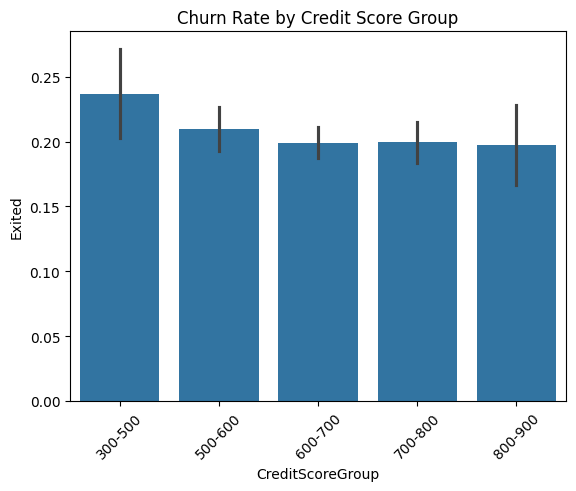

In [70]:
sns.barplot(x='CreditScoreGroup', y='Exited', data=df)
plt.title("Churn Rate by Credit Score Group")
plt.xticks(rotation=45)
plt.show()


In [71]:
df["EngagementScore"] = (
    df["IsActiveMember"]*2 +
    df["NumOfProducts"] +
    df["Tenure"]/5
)


In [72]:
df["EngagementScore"].head()


0    3.4
1    3.2
2    4.6
3    2.2
4    3.4
Name: EngagementScore, dtype: float64

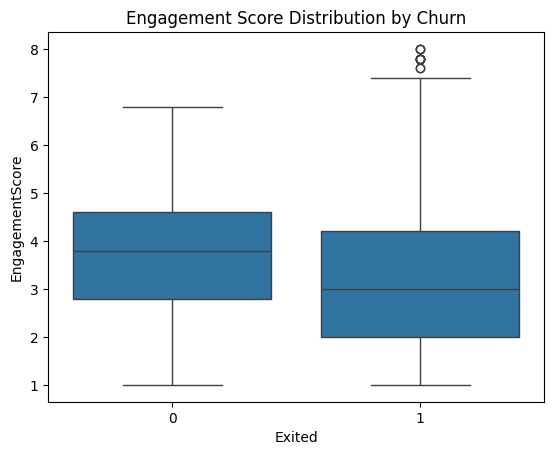

In [73]:
sns.boxplot(x="Exited", y="EngagementScore", data=df)
plt.title("Engagement Score Distribution by Churn")
plt.show()


In [74]:
Q1 = df['EngagementScore'].quantile(0.25)
Q3 = df['EngagementScore'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['EngagementScore'] > Q3 + 1.5*IQR) |
              (df['EngagementScore'] < Q1 - 1.5*IQR)]


In [75]:
Q1 = df['EngagementScore'].quantile(0.25)
Q3 = df['EngagementScore'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [76]:
df = df[(df['EngagementScore'] >= lower) &
        (df['EngagementScore'] <= upper)]


In [77]:
outliers = df[(df['EngagementScore'] < lower) |
              (df['EngagementScore'] > upper)]

len(outliers)


0

In [78]:
for val in df['Exited'].unique():
    subset = df[df['Exited'] == val]
    
    Q1 = subset['EngagementScore'].quantile(0.25)
    Q3 = subset['EngagementScore'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = subset[(subset['EngagementScore'] < lower) |
                      (subset['EngagementScore'] > upper)]
    
    print(f"Exited = {val}, Outliers = {len(outliers)}")


Exited = 1, Outliers = 5
Exited = 0, Outliers = 0


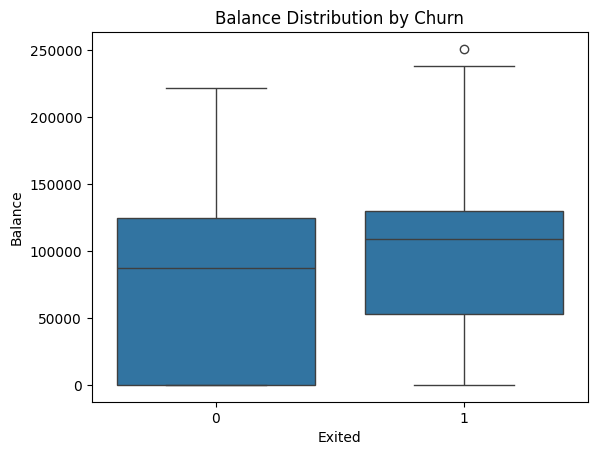

In [79]:
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance Distribution by Churn")
plt.show()


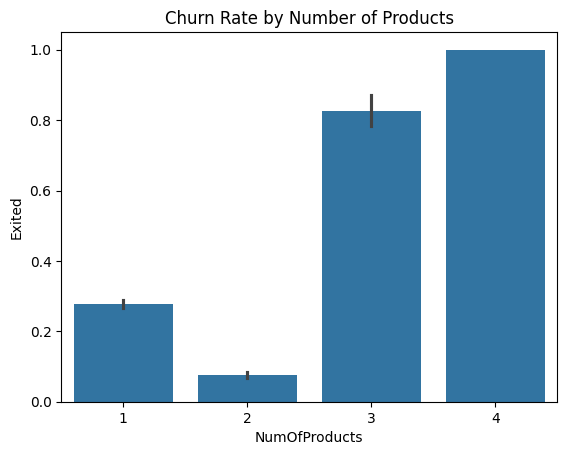

In [80]:
sns.barplot(x="NumOfProducts", y="Exited", data=df)
plt.title("Churn Rate by Number of Products")
plt.show()


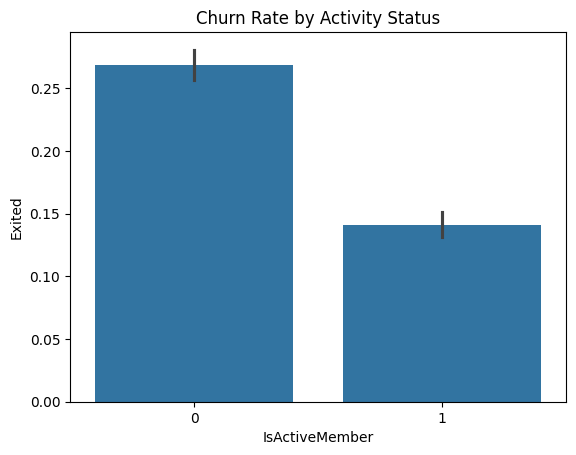

In [81]:
sns.barplot(x="IsActiveMember", y="Exited", data=df)
plt.title("Churn Rate by Activity Status")
plt.show()


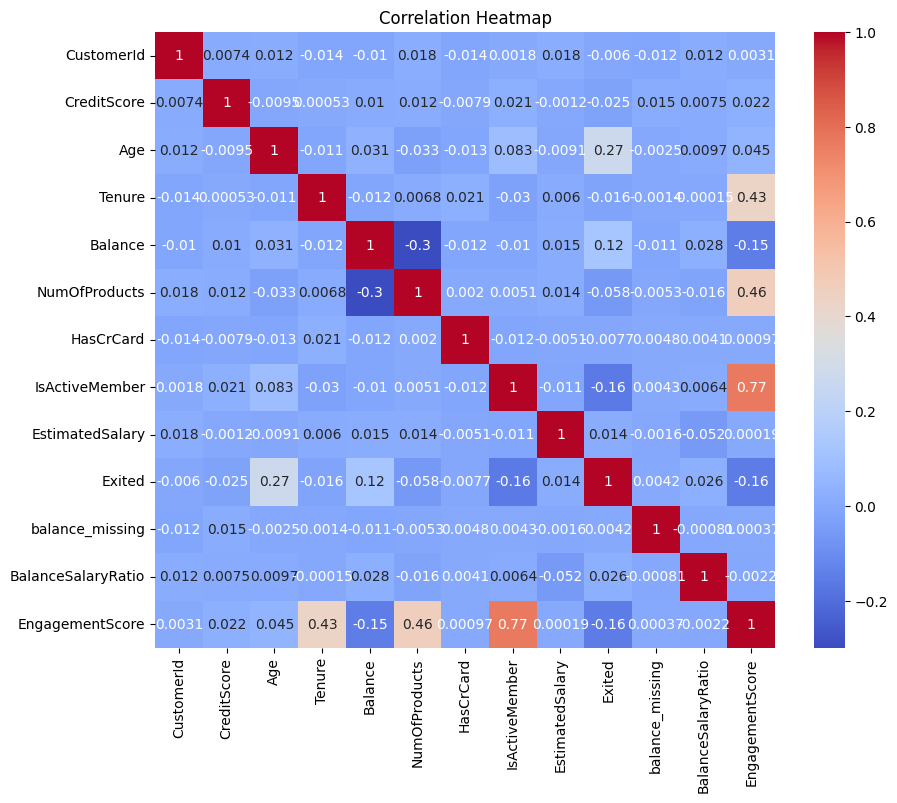

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


C:\Users\amald\AppData\Local\Temp\ipykernel_26152\401679951.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


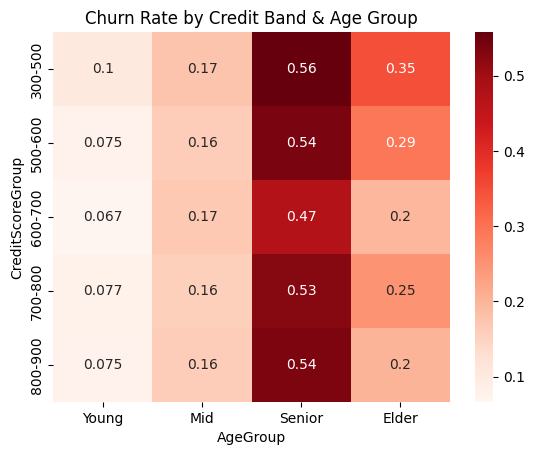

In [83]:
pivot = df.pivot_table(
    values="Exited",
    index="CreditScoreGroup",
    columns="AgeGroup",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Churn Rate by Credit Band & Age Group")
plt.show()
